# Installation et importation des bibliothèques

In [1]:
import time
print("---INSTALLATION DES BIBLIOTHEQUES EN COURS...---")
start_time = time.time()
!pip install -q monai[nibabel,pillow,itk]
!pip uninstall -y cupy cupy-cuda11x cupy-cuda12x
finish_time = time.time()
print(f"INSTALLATION DES BIBLIOTHEQUES FINIE EN {finish_time - start_time:.2f} SECONDES")

print("---IMPORTATION DES BIBLIOTHEQUES EN COURS...---")
start_time = time.time()
import gc
import glob
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import os
import random
import scipy.ndimage as ndimage
import torch
import torch.nn as nn
import torch.nn.functional as F

from google.colab import drive

# Importations MONAI
from monai.data import CacheDataset, DataLoader, Dataset
from monai.losses import DiceLoss, DiceCELoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric, SurfaceDistanceMetric
from monai.networks.nets import DynUNet
from monai.transforms import (
     AsDiscrete, CenterSpatialCropd, Compose, CopyItemsd, EnsureChannelFirstd, EnsureTyped, KeepLargestConnectedComponent, LoadImaged, RandGaussianSmoothd, Resized, ScaleIntensityd
)

# Importations Scikit-image pour la géométrie
from skimage.measure import label, regionprops, perimeter
from skimage.morphology import binary_erosion

# Importation des outils de précision mixte (AMP)
from torch.amp import autocast, GradScaler

from tqdm.notebook import tqdm

# Vérification du matériel (GPU ou CPU)
print("INITIALISATION DU MATERIEL ET DES DOSSIERS")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Calculs exécutés sur {device}")

finish_time = time.time()
print(f"IMPORTATION DES BIBLIOTHEQUES FINIE EN {finish_time - start_time:.2f} SECONDES")

---INSTALLATION DES BIBLIOTHEQUES EN COURS...---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.8 MB/s eta 0:00:00
Found existing installation: cupy-cuda12x 14.0.1
Uninstalling cupy-cuda12x-14.0.1:
  Successfully uninstalled cupy-cuda12x-14.0.1
INSTALLATION DES BIBLIOTHEQUES FINIE EN 34.55 SECONDES
---IMPORTATION DES BIBLIOTHEQUES EN COURS...---
INITIALISATION DU MATERIEL ET DES DOSSIERS
Calculs exécutés sur cuda
IMPORTATION DES BIBLIOTHEQUES FINIE EN 26.50 SECONDES


# Connection Drive et scan patients

In [2]:
if not os.path.exists('/content/drive'):
  drive.mount('/content/drive')
base_projet = '/content/drive/MyDrive/TFE_Segmentation'
root_dir = os.path.join(base_projet, 'Datasets', 'Task02_Heart')
os.makedirs(os.path.join(base_projet, '2D'), exist_ok=True)

print("---SCAN DES PATIENTS EN COURS...---")
start_time = time.time()
images = sorted(glob.glob(os.path.join(root_dir, "imagesTr", "*.nii.gz")))
labels = sorted(glob.glob(os.path.join(root_dir, "labelsTr", "*.nii.gz")))

# Appariement sécurisé par le nom de fichier pour éviter tout décalage
data = []
for img_path in images:
  nom_base = os.path.basename(img_path)
  lbl_path = next((lbl for lbl in labels if nom_base in lbl), None)
  if lbl_path:
    data.append({"image": img_path, "label":lbl_path})

if len(data) == 0:
  raise FileNotFoundError(f"Aucun couple image/label trouvé dans {root_dir}")
print(f"Nombre de patients Décathlon : {len(data)}")

# Fixation d'une graine aléatoire pour que le mélange soit reproductible à chaque lancement
random.seed(42)
random.shuffle(data)

# Découpage 4/5 entrainement et 1/5 validation
split_idx = int(len(data) * 0.8)
train_data = data[:split_idx]
val_data = data[split_idx:]

finish_time = time.time()
print(f"Patients d'entrainement : {len(train_data)}")
print(f"Patients de validation : {len(val_data)}")
print(f"SCAN DES PATIENTS FINI EN {finish_time - start_time:.2f} SECONDES")

Mounted at /content/drive
---SCAN DES PATIENTS EN COURS...---
Nombre de patients Décathlon : 20
Patients d'entrainement : 16
Patients de validation : 4
SCAN DES PATIENTS FINI EN 1.51 SECONDES


# Pipeline de transformation et extracteur de tranches 2D

In [3]:
transforms = Compose([
    # Chargement des volumes NiFTI (.nii.gz)
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),

    # Recadrage chirurgical : on se concentre uniquement sur la région centrale du coeur
    # -1 signifie qu'on conserve toutes les tranches Z du volume
    CenterSpatialCropd(keys=["image", "label"], roi_size=[192, 192, -1]),

    # Normalisation du contraste médical (0 à 1)
    ScaleIntensityd(keys="image"),

    # Duplication de l'image native
    # Servira de Verité terrain pour le SRCNN et de support pour la segmentation
    CopyItemsd(keys=["image"], names=["image_hr"]),

    # Simulation d'une dégradation IRM réaliste sur la clé 'image' qui devient la LR
    # Application d'un flou gaussien tranche par tranche pour casser les hautes fréquences avant de réduire la taille sur toutes les images
    RandGaussianSmoothd(
        keys="image", sigma_x=(0.5, 0.5), sigma_y=(0.5, 0.5),sigma_z=(0.0, 0.0),prob=1.0
    ),

    EnsureTyped(keys=["image", "image_hr", "label"]),
])

# Chargement initial en RAM via CacheDataset
print(f"---CHARGEMENT DU DATASET EN COURS...---")
start_time = time.time()
train_ds = CacheDataset(data=train_data, transform=transforms, cache_rate=1.0, num_workers=2)
val_ds = CacheDataset(data=val_data, transform=transforms, cache_rate=1.0, num_workers=2)
finish_time = time.time()
print(f"\nCHARGEMENT DU DATASET FINI EN {finish_time - start_time:.2f} SECONDES")

# Extraction multi-tranches qui isole toutes les coupes 2D contenant l'atrium
def extraire_tranches(dataset):
    tranches = []
    for data in dataset:
        # Forme des 3 tenseurs: [C, H, W, Z]
        vol_lr = data["image"] # Basse résolution
        vol_hr = data["image_hr"] # Haute résolution
        label_vol = data["label"] # Masque de segmentation

        # Détection des tranches où l'atrium est présent
        # Somme sur le canal et le plan spatial (C, H, W) -> dimension 3 correspond à 2
        dim_spatiales = (0, 1, 2)
        tranches_actives = torch.any(label_vol > 0, dim=dim_spatiales)

        # Récupération des indices Z valides instantanément
        indices_z = torch.where(tranches_actives)[0].cpu().tolist()

        # Extraction de la tranche centrale par sécurité si un volime n'a pas de masque
        if len(indices_z) == 0:
          indices_z = [label_vol.shape[-1] // 2]

        for z in indices_z:
          # Extraction directe [C, H, W] -> ajout dimension batch pour interpoler : [1, C, H, W]
          t_lr = vol_lr[..., z].unsqueeze(0)
          t_hr = vol_hr[..., z].unsqueeze(0)
          t_label = label_vol[..., z].unsqueeze(0).float()

          # Redimensionnement 2D strict, proche, étanche
          t_lr_128 = nn.functional.interpolate(t_lr, size=(128, 128), mode='bilinear', align_corners=False)
          t_hr_256 = nn.functional.interpolate(t_hr, size=(256, 256), mode='bilinear', align_corners=False)
          t_label_256 = nn.functional.interpolate(t_label, size=(256, 256), mode='nearest')

          # Squeeze uniquement sur la dimension 0 pour retrouver la forme propre [C, H, W]
          tranches.append({
              "image_lr": t_lr_128[0].clone(), # Forme [1, 128, 128]
              "image_hr": t_hr_256[0].clone(), # Forme [1, 256, 256]
              "label": t_label_256[0].clone()  # Forme [1, 256, 256]
          })

    if len(tranches) == 0:
        print("Aucun tranche trouvée")

    return tranches

# Extraction des tranches 2D dans des listes statiques avant de les envoyer au DataLoader
print("---EXTRACTION DES TRANCHES EN COURS...---")
start_time = time.time()
train_dataset_2d = extraire_tranches(train_ds)
val_dataset_2d = extraire_tranches(val_ds)

# On veut éviter les goulets d'étranglement CPU/RAM
train_loader = DataLoader(train_dataset_2d, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset_2d, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
finish_time = time.time()
print(f"Dataset prêt. Entrainement : {len(train_dataset_2d)} tranches / Validation : {len(val_dataset_2d)} tranches")
print(f"EXTRACTION DES TRANCHES FINIE EN {finish_time - start_time:.2f} SECONDES")

---CHARGEMENT DU DATASET EN COURS...---


Loading dataset: 100%|██████████| 4/4 [00:06<00:00,  1.60s/it]



CHARGEMENT DU DATASET FINI EN 44.23 SECONDES
---EXTRACTION DES TRANCHES EN COURS...---
Dataset prêt. Entrainement : 1081 tranches / Validation : 270 tranches
EXTRACTION DES TRANCHES FINIE EN 6.39 SECONDES


# Fonctions de perte, métriques, architectures réseaux

In [4]:
# Définition des métriques
# loss_function = DiceLoss(sigmoid=True)
loss_function = DiceCELoss(sigmoid=True, lambda_dice=0.5, lambda_ce=0.5)
loss_mse = nn.MSELoss() # Utilisé que pour la phase de pré-entrainement du SRCNN solo

# Métriques spatiales et surfaciques
assd_metric = SurfaceDistanceMetric(include_background=False, reduction="mean", symmetric=True)
hd95_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean")
dice_metric = DiceMetric(include_background=False, reduction="mean")

post_binarize = AsDiscrete(threshold=0.5) # Binarisation à 0.5 pour s'aligner sur la simgoid
keep_largest = KeepLargestConnectedComponent(applied_labels=[1]) # Cible la structure binaire

# Génération d'un modèle U-Net classique 2D
def creation_model():
  unet_model = DynUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    # 5 niveaux de profondeur (comme le nn-Unet par défaut pour ces tailles)
    kernel_size=[(3, 3),(3, 3),(3, 3),(3, 3),(3, 3)],
    strides=[(1, 1), (2, 2), (2, 2), (2, 2), (2, 2)],
    upsample_kernel_size=[(2, 2), (2, 2), (2, 2), (2, 2), (2, 2)],
    # Filtres plus larges pour capter les micro-détails de l'atrium
    filters=[64, 128, 256, 512, 1024],
    dropout=0.2,
    res_block=True,
  ).to(device)
  return unet_model

# Création d'un modèle SRCNN avec une connexion résiduelle globale
class SRCNN(nn.Module):
  def __init__(self):
    super(SRCNN, self).__init__()
    # Le réseau calcule tout en base résolution (128x128) sur 64 fonctionnaliés
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=9, padding=9 // 2)
    self.conv2 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=5, padding=5 // 2)

    # Sortie préparée pour un PixelShuffle de facteur x2 (1 canal de sortie * 4 canaux latents)
    self.conv3 = nn.Conv2d(in_channels=32, out_channels=4, kernel_size=5, padding=5 // 2)
    self.pixel_shuffle = nn.PixelShuffle(upscale_factor=2)
    self.relu = nn.ReLU(inplace=True)

  def forward(self, x):
    # Entrée x : tenseur LR [B, 1, 128, 128]/ Sortie : tenseur super résolu [B, 1, 256, 256]
    # Interpolation mathématique résiduelle pour stabiliser le PixelShuffle
    identity = nn.functional.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
    # Passage à travers les couches de convolution du SRCNN
    out = self.relu(self.conv1(x))
    out = self.relu(self.conv2(out))
    out = self.conv3(out)
    # Reconstruction sub-pixel vers l'échelle supérieure (256x256)
    res = self.pixel_shuffle(out)
    return torch.clamp(identity + res, 0.0, 1.0) # Addition de l'image floue et des détails fins reconstruits par l'IA

# Moteurs d'entrainement et de validation (multi-task loss et anti-air)

In [5]:
nb_epochs = 100

torch.backends.cudnn.benchmark = True
scaler = torch.amp.GradScaler()

def entrainement_model(num_cas, unet_model, srcnn_model, optimizer, nom_fichiers):
  print(f"---ENTRAINEMENT DU CAS {num_cas} SUR {nb_epochs} EPOQUES EN COURS...---")

  historique_trainloss, historique_valloss, historique_dice, historique_hausdorff, historique_assd = [], [], [], [], []
  meilleur_dice = 0.0
  start_time = time.time()

  # Initialisation du scaler pour la précision mixte (AMP)
  device_type = "cuda" if torch.cuda.is_available() else "cpu"
  scaler = GradScaler(enabled=(device_type == "cuda"))

  # Extraction propre des noms de fichiers (gère si c'est un tuple ou une chaîne unique)
  nom_unet = nom_fichiers[0] if isinstance(nom_fichiers, (tuple, list)) else nom_fichiers
  nom_srcnn = nom_fichiers[1] if (isinstance(nom_fichiers, (tuple, list)) and len(nom_fichiers) > 1) else "srcnn_default"

  for epoch in range(nb_epochs):
      unet_model.train()
      if num_cas == 4 and srcnn_model is not None:
        srcnn_model.train()
      elif srcnn_model is not None:
        srcnn_model.eval()

      running_loss = 0.0

      for batch_data in tqdm(train_loader, desc=f"Epoch : {epoch+1}/{nb_epochs}", leave=False):
          targets_hr = batch_data["image_hr"].to(device) # Tenseur de taille (256x256)
          inputs_lr = batch_data["image_lr"].to(device) # Tenseur de taille (128x128)
          inputs_labels = batch_data["label"].to(device) # Cible finale pour le UNET (256x256)

          optimizer.zero_grad()

          with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
            if num_cas == 1: # Baseline HR Native
              outputs = unet_model(targets_hr)
              loss = loss_function(outputs, inputs_labels)
            elif num_cas == 2: # Baseline LR (interpolation bilinéaire simple)
            # Interpolation bilinéaire logicielle standard (128x128 -> 256x256)
              inputs_upsampled = nn.functional.interpolate(inputs_lr, size=targets_hr.shape[2:], mode='bilinear', align_corners=False)
              outputs = unet_model(inputs_upsampled)
              loss = loss_function(outputs, inputs_labels)
            elif num_cas == 3: # Séquentiel (SRCNN pré-entrainé figé + U-Net)
              with torch.no_grad():
                inputs_sr = srcnn_model(inputs_lr)
              outputs = unet_model(inputs_sr.detach())
              loss = loss_function(outputs, inputs_labels)
            elif num_cas == 4: # Apprentissage conjoint (end-to-end) 100% Dice
              inputs_sr = srcnn_model(inputs_lr)
              outputs = unet_model(inputs_sr)

              # Ancrage multi-tache léger (99% Dice, 1% MSE)
              # Forcer le SRCNN à préserver les intensités de structure sans dériver en bruit
              loss_segmentation = loss_function(outputs, inputs_labels)
              loss_reconstruction = loss_mse(inputs_sr, targets_hr)
              loss = 0.95 * loss_segmentation + 0.05 * loss_reconstruction

          # Rétropropagation et mise à jour adaptées à la précision mixte AMP
          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()

          running_loss += loss.item()

      # Calcul de la perte d'entrainement moyenne pour l'époch
      train_loss = running_loss/len(train_loader)

      # Evaluation sur la partie validation
      val_loss, dice_score, hausdorff_score, assd_score = validation_model(num_cas, unet_model, srcnn_model, epoch)

      # Gestion de la continuité des métriques surfaciques sur les époques non calculées
      if hausdorff_score < 0:
        hausdorff_score = historique_hausdorff[-1] if len(historique_hausdorff) > 0 else 0.0
      if assd_score < 0:
        assd_score = historique_assd[-1] if len(historique_assd) > 0 else 0.0

      # Stockage des scores
      historique_trainloss.append(train_loss)
      historique_valloss.append(val_loss)
      historique_dice.append(dice_score)
      historique_hausdorff.append(hausdorff_score)
      historique_assd.append(assd_score)

      if dice_score > meilleur_dice:
        meilleur_dice = dice_score
        torch.save(unet_model.state_dict(), os.path.join(base_projet, '2D', f'deca_{nom_unet}.pth'))
        if num_cas == 4 and srcnn_model is not None:
          torch.save(srcnn_model.state_dict(), os.path.join(base_projet, '2D', f'deca_{nom_srcnn}.pth'))

  print(f"ENTRAINEMENT TERMINE EN {time.time()-start_time:.2f} SECONDES\n")
  resultats = {'Train Loss' : historique_trainloss, 'Val Loss': historique_valloss, 'Dice': historique_dice, 'HD95': historique_hausdorff, 'ASSD': historique_assd}
  return resultats


def validation_model(num_cas, unet_model, srcnn_model, epoch):
  unet_model.eval()
  if srcnn_model is not None:
    srcnn_model.eval()

  # Réinitialisation ultra-rapide des métriques existantes
  # Calcul des métriques surfaciques HD95 et ASSD toutes les 10 époques
  dice_metric.reset()
  hd95_metric.reset()
  assd_metric.reset()

  epoch_loss = 0.0
  device_type = "cuda" if torch.cuda.is_available() else "cpu"

  with torch.no_grad():
    for val_data in val_loader:
      # non_blocking+True permet de ne pas bloquer le CPU pendant le transfert vers le GPU
      val_targets_hr = val_data["image_hr"].to(device, non_blocking=True)
      val_inputs_lr = val_data["image_lr"].to(device, non_blocking=True)
      val_labels = val_data["label"].to(device, non_blocking=True)

      if num_cas == 1: # Baseline HR Native
        val_input = val_targets_hr
      elif num_cas == 2: # Baseline LR Bilinéaire
        val_upsampled = nn.functional.interpolate(val_inputs_lr, size=val_targets_hr.shape[2:], mode='bilinear', align_corners=False)
        val_input = val_upsampled
      elif num_cas in (3, 4): # Pipelined / Conjoint SRCNN -> U-Net
        val_input = srcnn_model(val_inputs_lr)

      # Evaluation sécurisée par l'autocast en validation
      with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
        # Prédiction UNet
        val_outputs = unet_model(val_input)
        loss_dice = loss_function(val_outputs, val_labels)
      epoch_loss += loss_dice.item()

      # Post-traitement, binarisation vectorielle
      val_outputs_prob = torch.sigmoid(val_outputs)
      #val_outputs_bin = post_binarize(val_outputs_prob)
      # Evaluation sur la binarisation brute à 50%
      val_bin = (val_outputs_prob > 0.5).float()

      # Vérification que les labels et les prédictions sont de même taille
      assert val_labels.shape == val_bin.shape, f"Les dimensions des labels {val_labels.shape} et des prédictions {val_bin.shape} ne correspondent pas."

      # Dice calculé au GPU
      dice_metric(y_pred=val_bin, y=val_labels)

      # Evaluation équitable sans sauter les tranches
      hd95_metric(y_pred=val_bin, y=val_labels)
      assd_metric(y_pred=val_bin, y=val_labels)

  # Calcul de la perte moyenne
  epoch_loss /= len(val_loader)

  # Agrégation Dice
  dice_res = dice_metric.aggregate()
  if isinstance(dice_res, (list,tuple)):
    dice_score = dice_res[0].item()
  else:
    dice_score = dice_res.item()

# Initialisation par défaut obligatoire pour éviter l'UnboundLocalError
  hd95_score = -1.0
  assd_score = -1.0

  # Agrégation HD95 / ASSD
  hd95_res = hd95_metric.aggregate()
  assd_res = assd_metric.aggregate()
  if isinstance(hd95_res, (list,tuple)):
    hd95_val = hd95_res[0].item()
  else:
    hd95_val = hd95_res.item()
  if isinstance(assd_res, (list,tuple)):
    assd_val = assd_res[0].item()
  else:
    assd_val = assd_res.item()

  if not np.isnan(hd95_val) and not np.isinf(hd95_val):
    hd95_score = float(hd95_val)
  else:
    hd95_score = 50.0
  if not np.isnan(assd_val) and not np.isinf(assd_val):
    assd_score = float(assd_val)
  else:
    assd_score = 20.0

  return epoch_loss, dice_score, hd95_score, assd_score

# Exécution des cas 1 à 4

In [7]:
"""# Fonction pour éviter la répétition du vidage de cache
def nettoyer_memoire_gpu(*objets):
  for obj in objets:
    if obj is not None:
      del obj
  torch.cuda.empty_cache()
  gc.collect()

print("LANCEMENT DES EXPERIENCES")
dossier_model = os.path.join(base_projet, '2D')
os.makedirs(dossier_model, exist_ok=True)
device_type = "cuda" if torch.cuda.is_available() else 'cpu'
"""

'# Fonction pour éviter la répétition du vidage de cache\ndef nettoyer_memoire_gpu(*objets):\n  for obj in objets:\n    if obj is not None:\n      del obj\n  torch.cuda.empty_cache()\n  gc.collect()\n\nprint("LANCEMENT DES EXPERIENCES")\ndossier_model = os.path.join(base_projet, \'2D\')\nos.makedirs(dossier_model, exist_ok=True)\ndevice_type = "cuda" if torch.cuda.is_available() else \'cpu\'\n'

In [8]:
"""# CAS 1 : Baseline Haute Résolution Native
unet_model1 = creation_model()
optimizer1 = torch.optim.Adam(unet_model1.parameters(), lr=0.001, weight_decay=1e-5) # Mise à jour des paramètres uniquement du UNet
resultats1 = entrainement_model(1, unet_model1, None, optimizer1, ('model1', ''))
nettoyer_memoire_gpu(unet_model1, optimizer1)"""

"# CAS 1 : Baseline Haute Résolution Native\nunet_model1 = creation_model()\noptimizer1 = torch.optim.Adam(unet_model1.parameters(), lr=0.001, weight_decay=1e-5) # Mise à jour des paramètres uniquement du UNet\nresultats1 = entrainement_model(1, unet_model1, None, optimizer1, ('model1', ''))\nnettoyer_memoire_gpu(unet_model1, optimizer1)"

In [9]:
"""# CAS 2 : Baseline Basse Résolution Interpolée
unet_model2 = creation_model()
optimizer2 = torch.optim.Adam(unet_model2.parameters(), lr=0.001, weight_decay=1e-5)
resultats2 = entrainement_model(2, unet_model2, None, optimizer2, ('model2', ''))
nettoyer_memoire_gpu(unet_model2, optimizer2)"""

"# CAS 2 : Baseline Basse Résolution Interpolée\nunet_model2 = creation_model()\noptimizer2 = torch.optim.Adam(unet_model2.parameters(), lr=0.001, weight_decay=1e-5)\nresultats2 = entrainement_model(2, unet_model2, None, optimizer2, ('model2', ''))\nnettoyer_memoire_gpu(unet_model2, optimizer2)"

In [10]:
"""# CAS 3 : Séquentiel Amont (Pré-entrainement SRCNN isolé puis U-Net)
print("Pré Entrainement du SRCNN re-résiduel isolé")
srcnn_solo = SRCNN().to(device)
optimizer_solo = torch.optim.Adam(srcnn_solo.parameters(), lr=0.001, weight_decay=1e-5)

# Initialisation du scaler pour le pré-entrainement autonome
scaler = GradScaler(enabled=(device_type == "cuda"))

# Compilation du SRCNN solo pour le pré-entrainement
for epoch in range(nb_epochs):
  srcnn_solo.train()
  running_mse = 0.0

  for batch_data in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{nb_epochs}", leave=False):
    targets_hr = batch_data["image_hr"].to(device, non_blocking=True) # Tenseur de taille (256x256)
    inputs_lr = batch_data["image_lr"].to(device, non_blocking=True) # Tenseur de taille (128x128)

    optimizer_solo.zero_grad()

    # Autocast pour aller 2x plus vite
    with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
      outputs = srcnn_solo(inputs_lr)
      loss = loss_mse(outputs, targets_hr)

    # Rétropropagation adaptée à la précision mixte AMP
    scaler.scale(loss).backward()
    scaler.step(optimizer_solo)
    scaler.update()

    running_mse += loss.item()

  # Calcul de la perte d'entrainement moyenne pour l'époch
  train_loss = running_mse/len(train_loader)

# Sauvegarde des poids natifs (non compilés)
torch.save(srcnn_solo.state_dict(), os.path.join(dossier_model, 'deca_srcnn_isole.pth'))
srcnn_solo.eval()

# Initialisation du modèle UNet pour le SRCNN solo
unet_model3 = creation_model()
optimizer3 = torch.optim.Adam(unet_model3.parameters(), lr=0.001, weight_decay=1e-5)
resultats3 = entrainement_model(3, unet_model3, srcnn_solo, optimizer3, ('model3', ''))
nettoyer_memoire_gpu(unet_model3, optimizer3, srcnn_solo, optimizer_solo)"""

'# CAS 3 : Séquentiel Amont (Pré-entrainement SRCNN isolé puis U-Net)\nprint("Pré Entrainement du SRCNN re-résiduel isolé")\nsrcnn_solo = SRCNN().to(device)\noptimizer_solo = torch.optim.Adam(srcnn_solo.parameters(), lr=0.001, weight_decay=1e-5)\n\n# Initialisation du scaler pour le pré-entrainement autonome\nscaler = GradScaler(enabled=(device_type == "cuda"))\n\n# Compilation du SRCNN solo pour le pré-entrainement\nfor epoch in range(nb_epochs):\n  srcnn_solo.train()\n  running_mse = 0.0\n\n  for batch_data in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{nb_epochs}", leave=False):\n    targets_hr = batch_data["image_hr"].to(device, non_blocking=True) # Tenseur de taille (256x256)\n    inputs_lr = batch_data["image_lr"].to(device, non_blocking=True) # Tenseur de taille (128x128)\n\n    optimizer_solo.zero_grad()\n\n    # Autocast pour aller 2x plus vite\n    with autocast(device_type=device_type, enabled=(device_type == \'cuda\')):\n      outputs = srcnn_solo(inputs_lr)\n      loss = 

In [11]:
"""# CAS 4 : Apprentissage conjoint End-to-End
unet_model4 = creation_model()
srcnn_joint = SRCNN().to(device)

# Chargement des poids su SRCNN pré-entrainé du cas 3
srcnn_joint.load_state_dict(torch.load(os.path.join(dossier_model, 'deca_srcnn_isole.pth'), map_location=device, weights_only=True))

# Un seul optimiseur conjoint pour mettre à jour le SRCNN ET le modèle avec LR différents
# Avec les paramètres bruts pour lier les gradients de manière transparente
optimizer4 = torch.optim.Adam([
    {'params': unet_model4.parameters(), 'lr': 1e-3},
    {'params': srcnn_joint.parameters(), 'lr': 1e-4}
], weight_decay = 1e-5)

resultats4 = entrainement_model(4, unet_model4, srcnn_joint, optimizer4, ('model4', 'srcnn4'))
nettoyer_memoire_gpu(unet_model4, optimizer4, srcnn_joint)"""

"# CAS 4 : Apprentissage conjoint End-to-End\nunet_model4 = creation_model()\nsrcnn_joint = SRCNN().to(device)\n\n# Chargement des poids su SRCNN pré-entrainé du cas 3\nsrcnn_joint.load_state_dict(torch.load(os.path.join(dossier_model, 'deca_srcnn_isole.pth'), map_location=device, weights_only=True))\n\n# Un seul optimiseur conjoint pour mettre à jour le SRCNN ET le modèle avec LR différents\n# Avec les paramètres bruts pour lier les gradients de manière transparente\noptimizer4 = torch.optim.Adam([\n    {'params': unet_model4.parameters(), 'lr': 1e-3},\n    {'params': srcnn_joint.parameters(), 'lr': 1e-4}\n], weight_decay = 1e-5)\n\nresultats4 = entrainement_model(4, unet_model4, srcnn_joint, optimizer4, ('model4', 'srcnn4'))\nnettoyer_memoire_gpu(unet_model4, optimizer4, srcnn_joint)"

# Evaluation des résultats

In [12]:
print("Evaluation des performances finales (Dice et HD95)")

chemin_model = os.path.join(base_projet, '2D')

# Instanciation des modèles
unet_model1, unet_model2, unet_model3, unet_model4 = [creation_model() for _ in range(4)]
srcnn_joint = SRCNN().to(device)
srcnn_solo = SRCNN().to(device)

modeles_unet = {
    'Cas 1 (Baseline HR)' : ('deca_model1.pth', unet_model1, None),
    'Cas 2 (Bicubique)' : ('deca_model2.pth', unet_model2, None),
    'Cas 3 (Séquentiel)' : ('deca_model3.pth', unet_model3, srcnn_solo),
    'Cas 4 (Conjoint)' : ('deca_model4.pth', unet_model4, srcnn_joint)
}

# Chargement du SRCNN pré-entrainé
if os.path.exists(os.path.join(chemin_model, 'deca_srcnn4.pth')):
  srcnn_joint.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn4.pth'), map_location=device, weights_only=True))
if os.path.exists(os.path.join(chemin_model, 'deca_srcnn_isole.pth')):
  srcnn_solo.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn_isole.pth'), map_location=device, weights_only=True))

srcnn_joint.eval()
srcnn_solo.eval()

resultats_finaux = []

for nom_cas, (fichier, modele, srcnn) in modeles_unet.items():
  path = os.path.join(chemin_model, fichier)
  if not os.path.exists(path):
    print(f"Fichier {fichier} introuvable dans le Drive")
    continue

  modele.load_state_dict(torch.load(path, map_location=device, weights_only=True))
  modele.eval()
  if srcnn:
    srcnn.eval()

  # Réinitialisation des métriques
  dice_metric.reset()
  hd95_metric.reset()

  device_type = "cuda" if torch.cuda.is_available() else "cpu"
  with torch.no_grad():
    for batch_data in val_loader:
      val_targets_hr = batch_data['image_hr'].to(device, non_blocking=True)
      val_inputs_lr = batch_data['image_lr'].to(device, non_blocking=True)
      val_labels = batch_data['label'].to(device, non_blocking=True)

      if 'Cas 1' in nom_cas:
        val_input = val_targets_hr
      elif 'Cas 2' in nom_cas:
        val_input = F.interpolate(val_inputs_lr, size=val_targets_hr.shape[2:], mode='bilinear', align_corners=False)
      elif 'Cas 3' in nom_cas or 'Cas 4' in nom_cas:
        val_input = srcnn(val_inputs_lr)

      with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
        val_outputs = modele(val_input)

      val_outputs_prob = torch.sigmoid(val_outputs)

      val_bin = (val_outputs_prob > 0.5).float()
      val_labels_bin = val_labels.float()

      # Vérification que les labels et les prédictions sont de même taille
      assert val_labels_bin.shape == val_bin.shape, f"Les dimensions des labels {val_labels_bin.shape} et des prédictions {val_bin.shape} ne correspondent pas."

      dice_metric(y_pred=val_bin, y=val_labels_bin)
      hd95_metric(y_pred=val_bin, y=val_labels_bin)

  # Calcul des scores moyens
  dice_res = dice_metric.aggregate()
  if isinstance(dice_res, (list,tuple)):
    dice_score = dice_res[0].item()
  else:
    dice_score = dice_res.item()

  hd95_res = hd95_metric.aggregate()
  if isinstance(hd95_res, (list,tuple)):
    hd95_val = hd95_res[0].item()
  else:
    hd95_val = hd95_res.item()

  if not np.isnan(hd95_val) and not np.isinf(hd95_val):
    hd95_score = float(hd95_val)
  else:
    hd95_score = 50.0

  resultats_finaux.append({
      'Cas' : nom_cas,
      'Dice Final' : round(dice_score, 4),
      'HD95 Final (voxels)' : round(hd95_score, 4)
  })

df_finaux = pd.DataFrame(resultats_finaux)
print("Tableau comparatif")
print(df_finaux.to_string(index=False))

# Sauvegarde du tableau
df_finaux.to_csv(os.path.join(chemin_model, 'deca_tableau_perf.csv'), index=False)

Evaluation des performances finales (Dice et HD95)


monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
the prediction of class 0 is all 0, this may result in nan/inf distance.


Tableau comparatif
                Cas  Dice Final  HD95 Final (voxels)
Cas 1 (Baseline HR)      0.8239              12.2009
  Cas 2 (Bicubique)      0.8371               8.9357
 Cas 3 (Séquentiel)      0.8349              12.2311
   Cas 4 (Conjoint)      0.8346              14.9497


# Comparaison visuelle

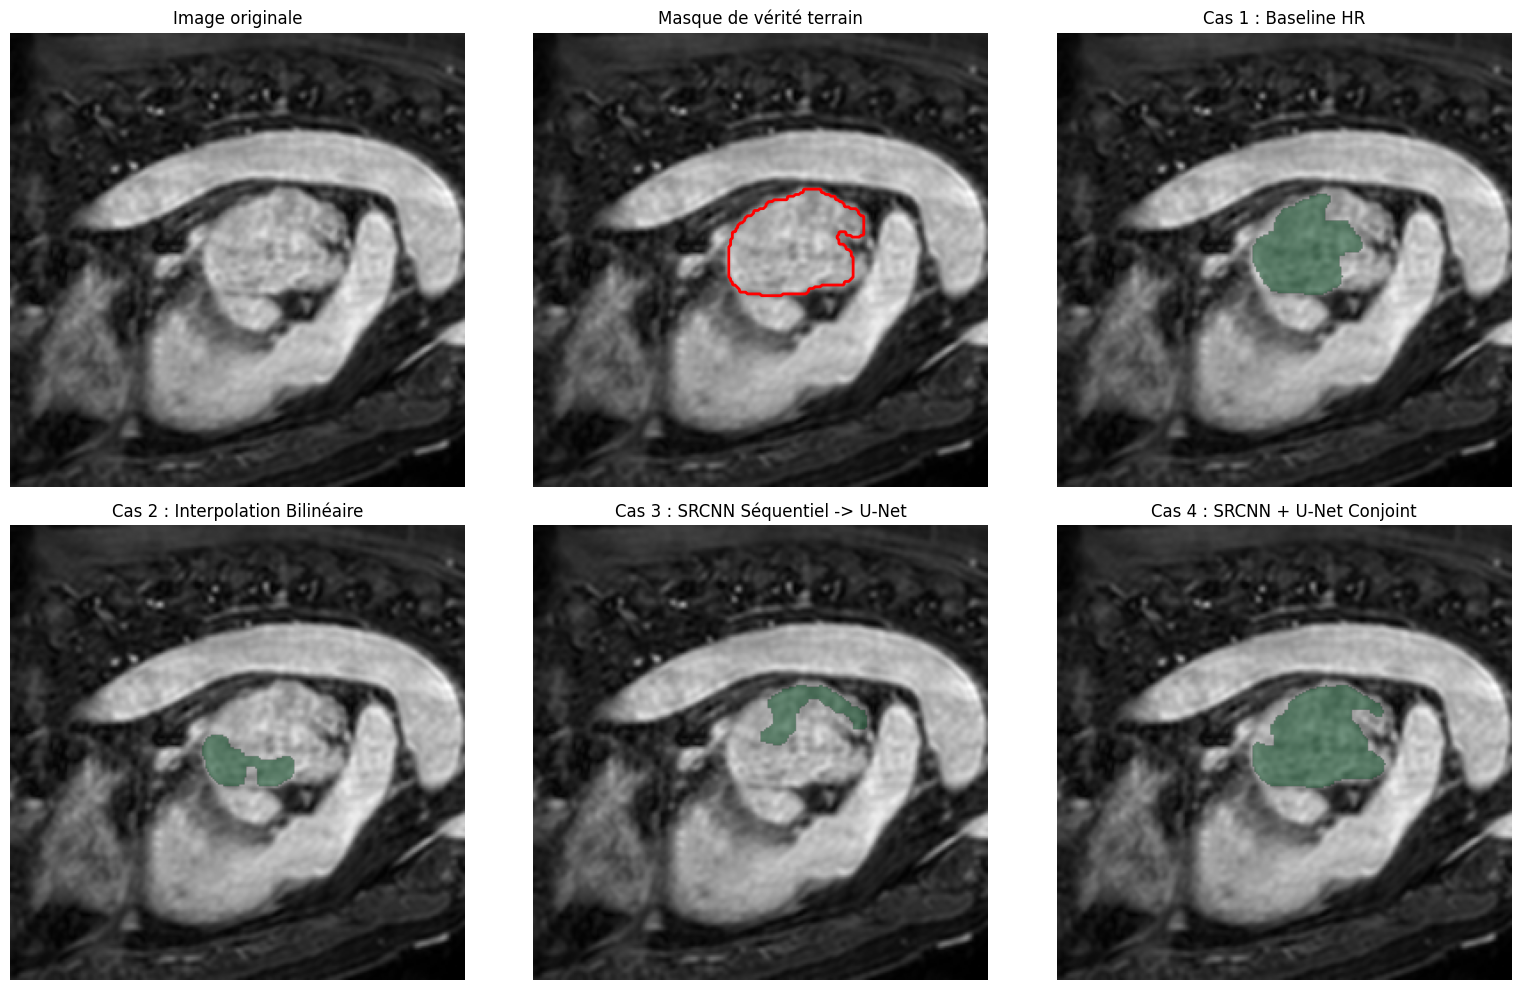

Visualisation enregistrée dans : /content/drive/MyDrive/TFE_Segmentation/2D


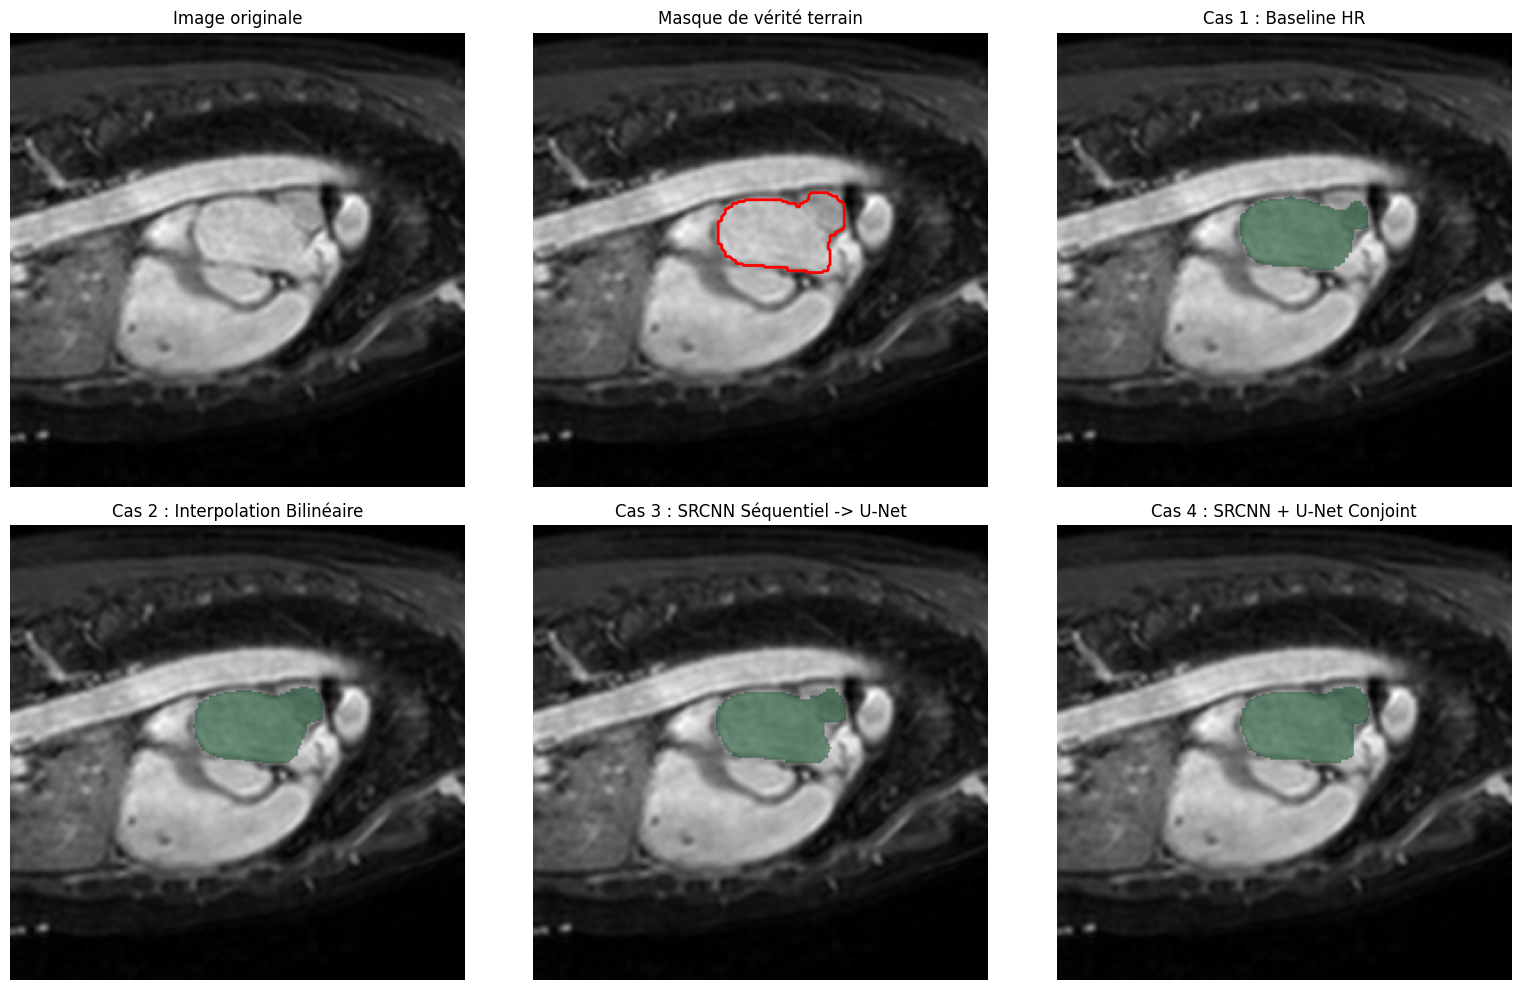

Visualisation enregistrée dans : /content/drive/MyDrive/TFE_Segmentation/2D


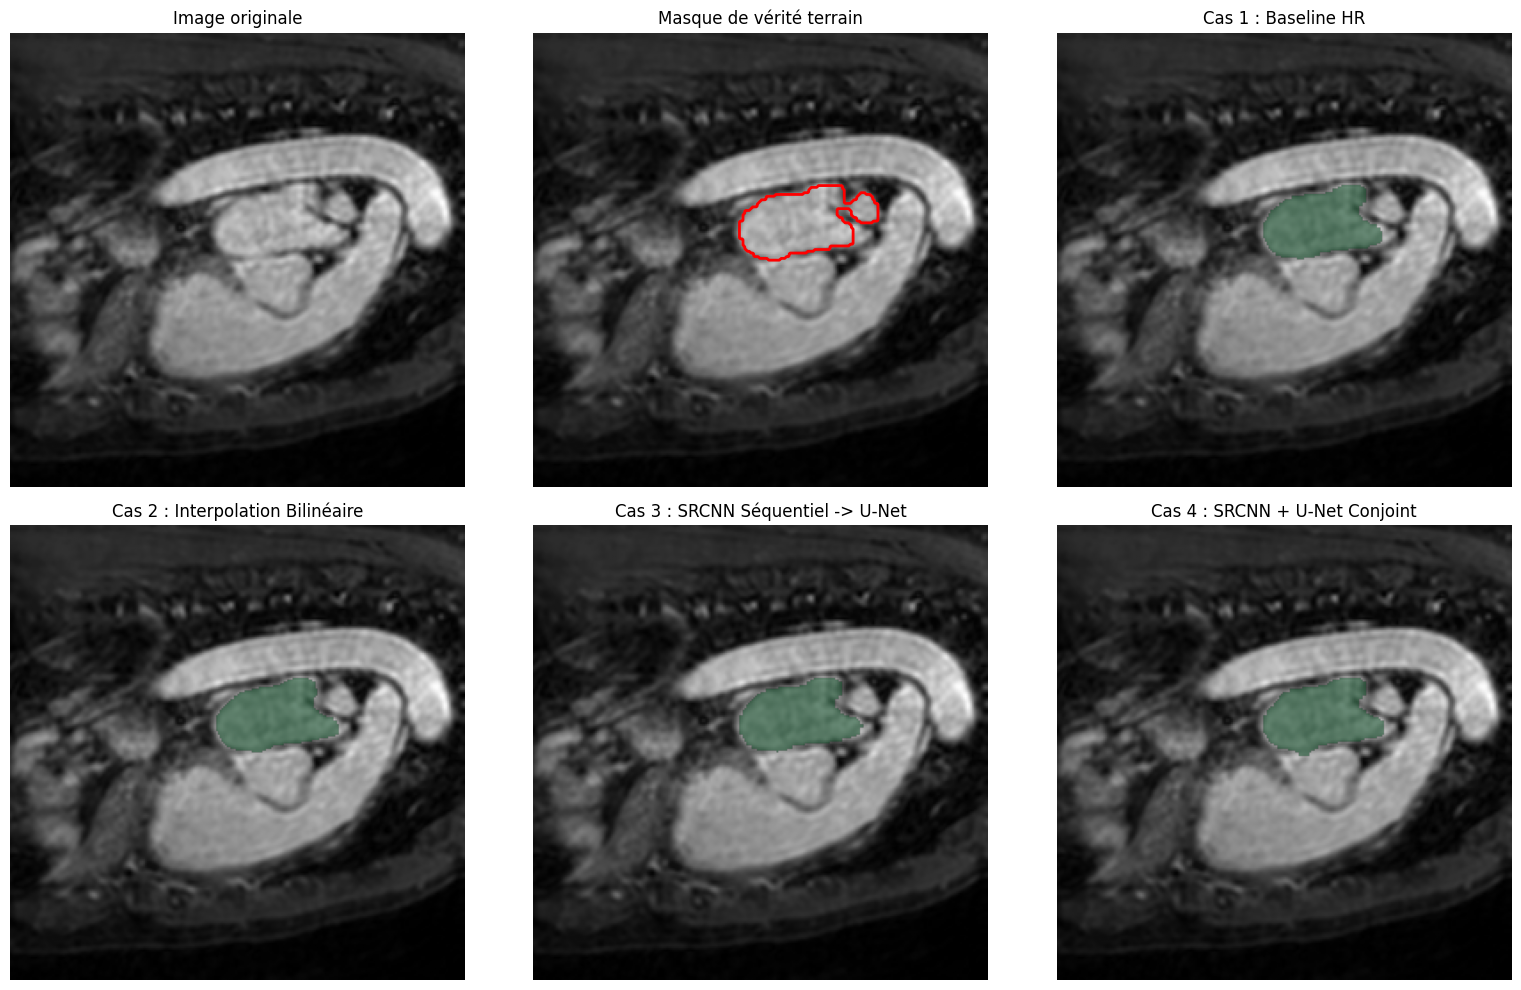

Visualisation enregistrée dans : /content/drive/MyDrive/TFE_Segmentation/2D


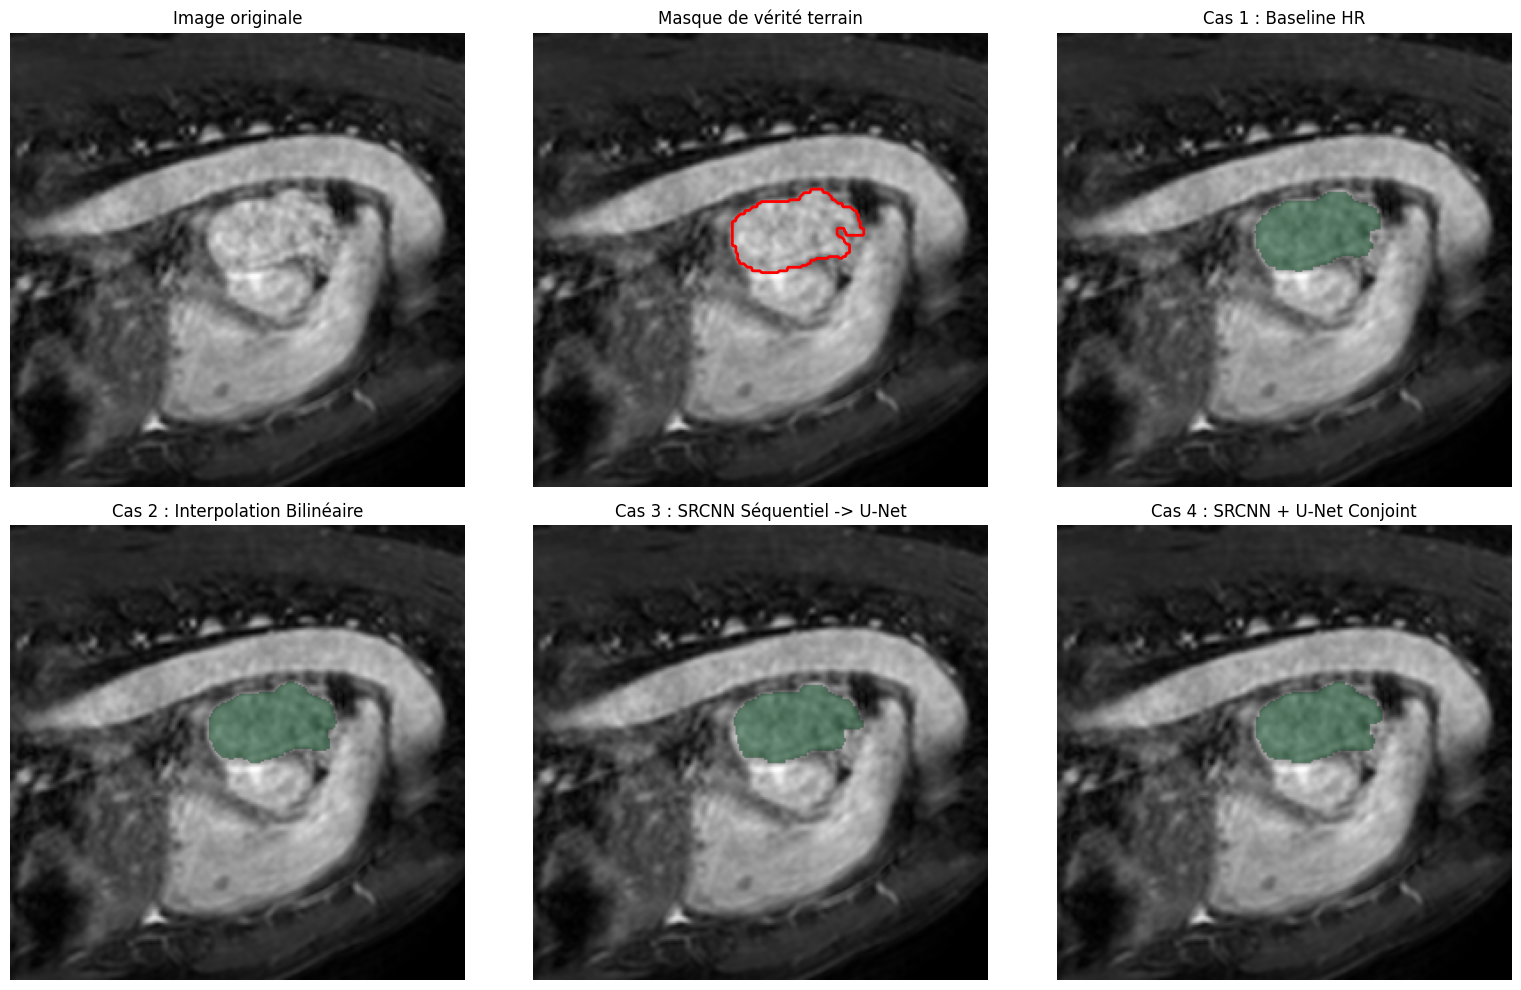

Visualisation enregistrée dans : /content/drive/MyDrive/TFE_Segmentation/2D


In [13]:
def afficher_comparaison_visuelle(idx_batch):
  # Recréation des modèles vides pour accueillir les poids
  unet_model1, unet_model2, unet_model3, unet_model4 = [creation_model() for _ in range(4)]
  srcnn_joint = SRCNN().to(device)
  srcnn_solo = SRCNN().to(device)

  # Chargement des meilleurs poids sauvegardés pour chaque modèle
  chemin_model = os.path.join(base_projet, '2D')

  # Dictionnaire de correspondance pour faciliter le chargement
  modeles_unet = {'deca_model1.pth': unet_model1, 'deca_model2.pth': unet_model2, 'deca_model3.pth': unet_model3, 'deca_model4.pth': unet_model4}

  # Boucle de chargement
  for nom_fichier, modele in modeles_unet.items():
    chemin_complet = os.path.join(chemin_model, nom_fichier)
    if os.path.exists(chemin_complet):
      modele.load_state_dict(torch.load(chemin_complet, map_location=device, weights_only=True))
      modele.eval()

  if os.path.exists(os.path.join(chemin_model, 'deca_srcnn.pth')):
    srcnn_joint.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn.pth'), map_location=device, weights_only=True))
  if os.path.exists(os.path.join(chemin_model, 'deca_srcnn_isole.pth')):
    srcnn_solo.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn_isole.pth'), map_location=device, weights_only=True))

  srcnn_joint.eval()
  srcnn_solo.eval()

  # Extraction sécurisée du batch sans crash d'itérateur et sans charger tout le DataLoader en RAM
  it = iter(val_loader)
  for _ in range(idx_batch):
    try:
      next(it)
    except StopIteration:
      it = iter(val_loader)
      break
  batch = next(it)

  # Sélection intelligente du meilleur échantillon (avec le plus gros masque)
  label_batch = batch["label"]
  somme_pixels = torch.sum(label_batch, dim=(1, 2, 3))
  idx_echantillon = torch.argmax(somme_pixels).item()

  if somme_pixels[idx_echantillon] == 0:
    print("Attention : Aucun masque expert trouvé dans ce batch.")

  # Extraction de l'image et du masque de vérité terrain (Ground Terrain) [1, C, H, W]
  img_hr = batch["image_hr"][idx_echantillon:idx_echantillon+1].to(device)
  img_lr = batch["image_lr"][idx_echantillon:idx_echantillon+1].to(device)
  label_gt = batch["label"][idx_echantillon:idx_echantillon+1].to(device)

  device_type = "cuda" if torch.cuda.is_available() else "cpu"
  seuil_confiance = 0.5
  # Définition d'un pinceau carré de 5x5 pixels pour forcer la fusion des îlots
  structure = np.ones((5, 5))

  predictions = []

  with torch.no_grad():
    with autocast(device_type=device_type, enabled=(device_type == 'cuda')):

      # Génération dynamique des entrées pour éviter le hardcoding
      taille_cible = img_hr.shape[2:]
      entrees_cas = [img_hr, nn.functional.interpolate(img_lr, size=taille_cible, mode='bilinear', align_corners=False), srcnn_solo(img_lr), srcnn_joint(img_lr)]

      modeles_cas = [unet_model1, unet_model2, unet_model3, unet_model4]

      # Boucle sur les 4 cas
      for entree, modele in zip(entrees_cas, modeles_cas):
        output = modele(entree)
        pred_prob = (torch.sigmoid(output) > seuil_confiance).float()
        pred = keep_largest(pred_prob)

        # Conversion Numpy et application directe de la morphologie mathématique
        pred_np = pred[0, 0].cpu().numpy()
        pred_morpho = ndimage.binary_fill_holes(ndimage.binary_closing(pred_np, structure=structure)).astype(float)
        predictions.append(pred_morpho)


  # Conversion des tenseurs en Numpy pour matplotlib
  img_display = img_hr[0, 0].cpu().numpy()
  label_display = label_gt[0, 0].cpu().numpy()

  # Affichage des images
  plt.figure(figsize=(16, 10))

  # Image d'origine (HR)
  plt.subplot(2, 3, 1)
  plt.imshow(img_display, cmap='gray')
  plt.title('Image originale')
  plt.axis('off')

  # Masque de vérité terrain (Ground Truth)
  plt.subplot(2, 3, 2)
  plt.imshow(img_display, cmap='gray')
  # Contour de l'expert en fond (rouge)
  if np.max(label_display) > 0:
    plt.contour(label_display, colors='red', linewidths=2, levels=[0.5])
  plt.title('Masque de vérité terrain')
  plt.axis('off')

  # 4 cas d'études
  titres_cas = ['Cas 1 : Baseline HR', 'Cas 2 : Interpolation Bilinéaire', 'Cas 3 : SRCNN Séquentiel -> U-Net', 'Cas 4 : SRCNN + U-Net Conjoint']
  positions_cas = [3, 4, 5, 6]

  for pos, pred, titre in zip(positions_cas, predictions, titres_cas):
    plt.subplot(2, 3, pos)
    plt.imshow(img_display, cmap='gray')
    # Contour du modèle par dessus (vert)
    if np.max(pred) > 0:
      # Masquage des pixels à O pour ne pas colorer le fond en noir, et affichage des pixels = 1 en vert
      masque_vert = np.ma.masked_where(pred == 0, pred)
      plt.imshow(masque_vert, cmap='Greens', alpha=0.5, vmin=0, vmax=1)
    plt.title(titre)
    plt.axis('off')

  plt.tight_layout()
  chemin_sauvegarde = os.path.join(chemin_model, f'deca_comparaison_visuelle_{idx_batch}.png')
  plt.savefig(chemin_sauvegarde, dpi=300, bbox_inches='tight')
  plt.show()
  print(f"Visualisation enregistrée dans : {chemin_model}")

for i in range(4):
  afficher_comparaison_visuelle(i)

# Diagnostic d'anomalies cardiaques et cartographie EDT

Patient 1
Topologie Expert : 2 composantes connexes
Topologie Modèle : 1 composantes connexes
Surface Expert : 561 pixels
Surface Modèle : 424 pixels
Erreur relative : -24.42%
Patient 2
Topologie Expert : 2 composantes connexes
Topologie Modèle : 1 composantes connexes
Surface Expert : 776 pixels
Surface Modèle : 563 pixels
Erreur relative : -27.45%
Patient 3
Topologie Expert : 2 composantes connexes
Topologie Modèle : 1 composantes connexes
Surface Expert : 937 pixels
Surface Modèle : 551 pixels
Erreur relative : -41.20%
Patient 4
Topologie Expert : 2 composantes connexes
Topologie Modèle : 1 composantes connexes
Surface Expert : 1132 pixels
Surface Modèle : 717 pixels
Erreur relative : -36.66%


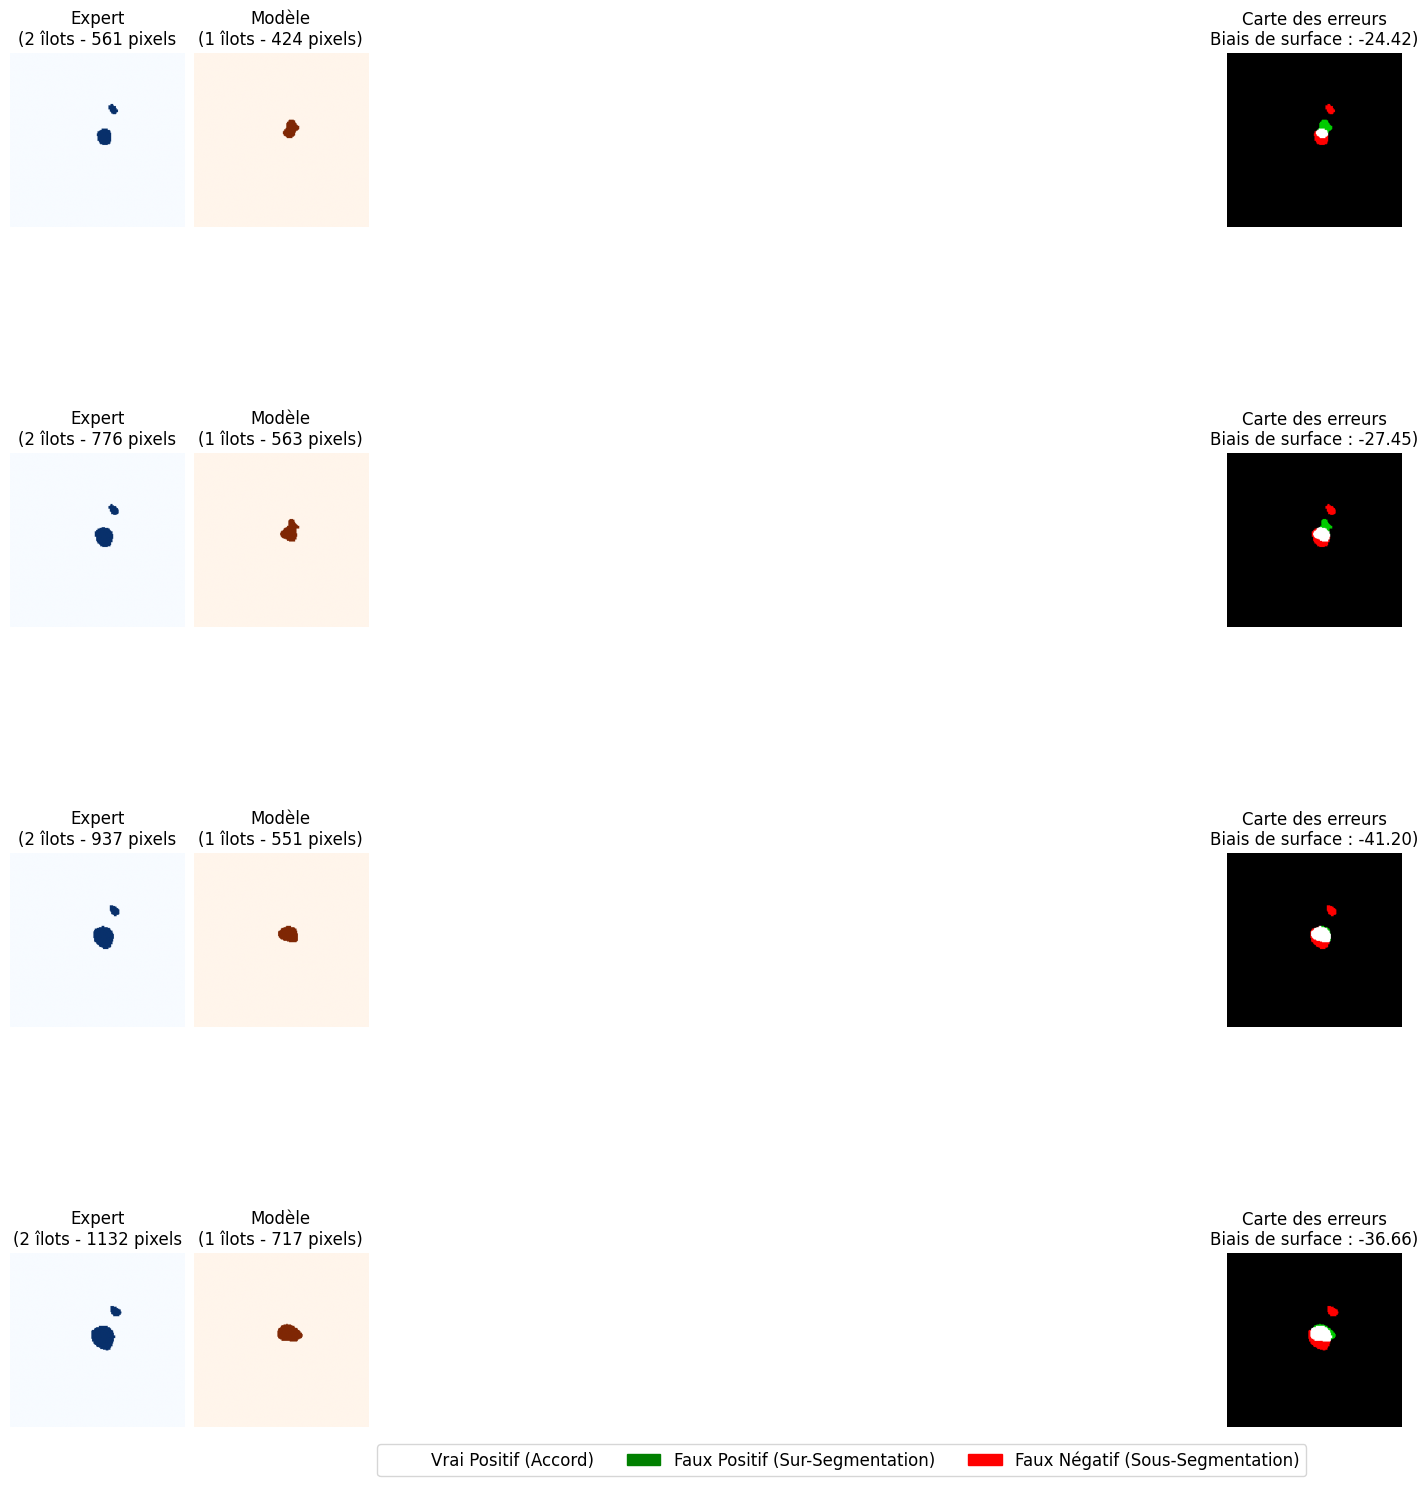

In [14]:
def analyser_topologie(masque_binaire):
  # Compte le nombre de composantes connexes (îlots) dans le masque
  masque_label = label(masque_binaire.astype(bool))
  nb_composantes = np.max(masque_label)
  return nb_composantes

def generer_carte_erreurs_cliniques(masque_expert, masque_predit):
  # Génération d'une carte RVB des erreurs :
  # Blanc : Vrai Positif (TP)
  # Vert : Faux Positif (FP) - Sur-segmentation
  # Rouge : Faux Négatif (FN) - Sous-segmentation
  expert_bool = masque_expert.astype(bool)
  pred_bool = masque_predit.astype(bool)

  # Calcul des masques logiques
  TP = expert_bool & pred_bool
  FP = pred_bool & ~expert_bool
  FN = expert_bool & ~pred_bool

  # Création de l'image RVB (H, W, 3)
  carte_rvb = np.zeros((masque_expert.shape[0], masque_expert.shape[1], 3), dtype=np.float32)

  # Remplissage des couleurs
  carte_rvb[TP] = [1.0, 1.0, 1.0] #Blanc
  carte_rvb[FP] = [0.0, 0.8, 0.0] #Vert
  carte_rvb[FN] = [1.0, 0.0, 0.0] #Rouge

  # Calcul des métriques de surface
  surface_expert = np.sum(expert_bool)
  surface_pred = np.sum(pred_bool)
  delta_surface = surface_pred - surface_expert

  # Erreur relative en pourcentage
  erreur_relative = (delta_surface / surface_expert) * 100 if surface_expert > 0 else 0.0

  return carte_rvb, surface_expert, surface_pred, erreur_relative

def executer_diagnostic_anomalies(nb_patients):
    """
    Exécute le pipeline complet de détection d'anomalies morphologiques et affiche
    un rapport clinique comparatif détaillé avec graphiques.
    """
    chemin_model = os.path.join(base_projet, '2D')

    # Chargement des modèles avec suffixe _nn
    unet_model4.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_model3.pth'), map_location=device, weights_only=True))
    if os.path.exists(os.path.join(chemin_model, 'deca_srcnn.pth')):
      srcnn_joint.load_state_dict(torch.load(os.path.join(chemin_model, 'deca_srcnn.pth'), map_location=device, weights_only=True))

    unet_model4.eval()
    srcnn_joint.eval()

    device_type = "cuda" if torch.cuda.is_available() else "cpu"

    # Sélection intelligente des tranches centrales
    tranches_utiles = []
    for data in val_dataset_2d:
      # Garde uniquement les tranches où le masque expert fait au moins 150 pixels de surface
      if torch.sum(data['label']) > 150:
        tranches_utiles.append(data)
      if len(tranches_utiles) == nb_patients:
        break

    if len(tranches_utiles) == 0:
      print("Erreur : Aucune tranche avec un atrium assez grand n'a été trouvée")
      return

    fig, axes = plt.subplots(nb_patients, 3, figsize=(14, 4*nb_patients), squeeze=False, constrained_layout=True)

    with torch.no_grad():
      # Boucle sur les tranches massives fraîchement sélectionnées
      for i in range(len(tranches_utiles)):
        patient = tranches_utiles[i]

        # Reconstruction 4D voulue par PyTorch : [H, W] -> [B=1, C=1, H, W]
        img_lr = patient['image_lr'].unsqueeze(0).to(device)
        label_gt = patient['label'].unsqueeze(0).to(device)

        # Inférence Cas 4 Conjoint sécurisée sous AMP
        with autocast(device_type=device_type, enabled=(device_type == 'cuda')):
          img_srcnn_joint = srcnn_joint(img_lr)
          output_model4 = unet_model4(img_srcnn_joint.float())

          # Nettoyage topologique de la prédiction
          pred_prob = (torch.sigmoid(output_model4) > 0.5).float()
          pred_model = keep_largest(pred_prob)

          # Fermeture morphologique pour lisser
          structure = np.ones((5, 5))
          pred_np = pred_model[0, 0].cpu().numpy()
          pred_display = ndimage.binary_fill_holes(ndimage.binary_closing(pred_np, structure=structure)).astype(float)

        # Reconversion en tableaux Numpy pour Scipy/Matplotlib
        label_display = label_gt[0, 0].cpu().numpy()

        # Analyse topologique
        nb_ilots_expert = analyser_topologie(label_display)
        nb_ilots_pred = analyser_topologie(pred_display)

        # Analyse des erreurs et des surfaces
        carte_rvb, surface_expert, surface_pred, erreur_relative = generer_carte_erreurs_cliniques(label_display, pred_display)

        # Affichage console
        print(f"Patient {i+1}")
        print(f"Topologie Expert : {nb_ilots_expert} composantes connexes")
        print(f"Topologie Modèle : {nb_ilots_pred} composantes connexes")
        print(f"Surface Expert : {surface_expert} pixels")
        print(f"Surface Modèle : {surface_pred} pixels")
        print(f"Erreur relative : {erreur_relative:+.2f}%")

        # Colonne 1 : Vérité terrain
        axes[i, 0].imshow(label_display, cmap='Blues')
        axes[i, 0].set_title(f"Expert\n({nb_ilots_expert} îlots - {surface_expert} pixels")
        axes[i, 0].axis('off')

        # Colonne 2 : Prédiction modèle
        axes[i, 1].imshow(pred_display, cmap='Oranges')
        axes[i, 1].set_title(f"Modèle\n({nb_ilots_pred} îlots - {surface_pred} pixels)")
        axes[i, 1].axis('off')

        # Colonne 3 : Carte d'erreurs FP/FN
        axes[i, 2].imshow(carte_rvb)
        axes[i, 2].set_title(f"Carte des erreurs\nBiais de surface : {erreur_relative:.2f})")
        axes[i, 2].axis('off')

    # Légende personnalisée pour la carte RVB
    patch_tp = mpatches.Patch(color='white', label='Vrai Positif (Accord)')
    patch_fp = mpatches.Patch(color='green', label='Faux Positif (Sur-Segmentation)')
    patch_fn = mpatches.Patch(color='red', label='Faux Négatif (Sous-Segmentation)')
    plt.legend(handles=[patch_tp, patch_fp, patch_fn], loc='upper right', ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.05))

    # Sauvegarde
    plt.savefig(os.path.join(base_projet, '2D', 'deca_diagnostic.png'), dpi=300, facecolor='black', bbox_inches='tight')
    plt.show()

executer_diagnostic_anomalies(nb_patients=4)

# Contexte clinique

invalid escape sequence '\P'
invalid escape sequence '\P'
invalid escape sequence '\P'


Détection de fibrillation auriculaire
\Patient 1 : 
Surface totale détectée : 5.06 cm2
Diagnostic : Normal
\Patient 2 : 
Surface totale détectée : 7.00 cm2
Diagnostic : Normal
\Patient 3 : 
Surface totale détectée : 3.50 cm2
Diagnostic : Normal


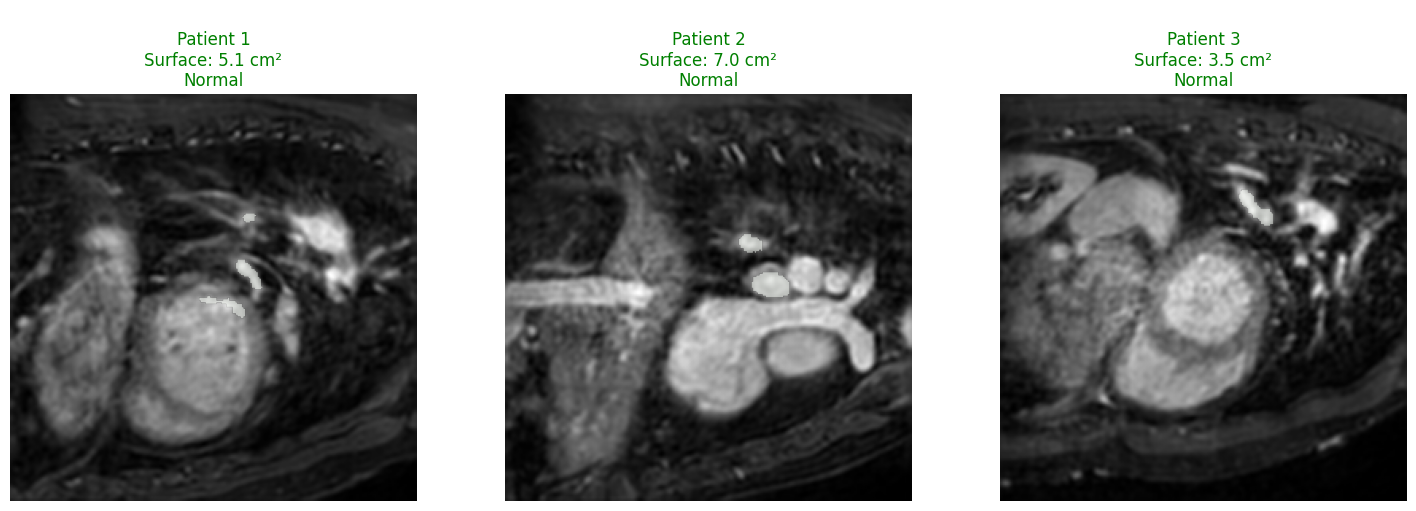

In [15]:
def diagnostic_clinique(nb_patients):
  print("Détection de fibrillation auriculaire")

  surface_pixel_cm2 = 0.015625
  seuil_dilatation_cm2 = 20.0 # Seuil clinique critique

  # Meilleur cas : 3
  unet_champion = unet_model3
  srcnn_champion = srcnn_solo
  unet_champion.eval()
  srcnn_champion.eval()

  # Récupération de quelques images du DataLoader de validation
  it = iter(val_loader)

  fix, axes = plt.subplots(1, nb_patients, figsize=(5 * nb_patients, 5))
  if nb_patients == 1:
    axes = [axes]

  with torch.no_grad():
    for i in range(nb_patients):
      try:
        batch = next(it)
      except StopIteration:
        break

      img_lr = batch["image_lr"][0:1].to(device)

      # Inférence
      img_sr = srcnn_champion(img_lr)
      output = unet_champion(img_sr.float())
      pred_binaire = (torch.sigmoid(output) > 0.5).float()

      # Conversion Numpy
      pred_np = pred_binaire[0, 0].cpu().numpy()

      # Calcul clinique
      nb_pixels = np.sum(pred_np == 1)
      surface_totale_cm2 = nb_pixels * surface_pixel_cm2

      # Affichage console
      print(f"\Patient {i+1} : ")
      print(f"Surface totale détectée : {surface_totale_cm2:.2f} cm2")

      # Diagnostic
      if surface_totale_cm2 > seuil_dilatation_cm2:
        diagnostic = "Dilatation (RISQUE FA)"
        couleur_alerte = 'red'
        print(f"Diagnostic : {diagnostic}")
      else:
        diagnostic = "Normal"
        couleur_alerte = 'green'
        print(f"Diagnostic : {diagnostic}")

      # Affichage visuel
      axes[i].imshow(img_sr[0, 0].cpu().numpy(), cmap='gray')
      masque_vert = np.ma.masked_where(pred_np == 0, pred_np)
      axes[i].imshow(masque_vert, cmap='Greens', alpha=0.5)

      axes[i].set_title(f"\nPatient {i+1}\nSurface: {surface_totale_cm2:.1f} cm²\n{diagnostic}", color=couleur_alerte)
      axes[i].axis('off')

  plt.tight_layout()
  plt.show()

# Lancement du diagnostic sur 3 patients
diagnostic_clinique(3)